In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#parameters
Ej = 50e3
Ec = 230
d = 0
phi_0 = 1.0
ng = 0
g = 80
fc = 6e3
kappa = 1e6
gamma = 1000e6
n_th = 0.1

N_q = 10  #qubit levels
N_c = 10  #cavity levels

def get_flux_hamiltonian(phi):
    #flux-dependent tunneling energy
    cos_term = np.cos(np.pi*phi / phi_0)
    sin_term = np.sin(np.pi*phi / phi_0)
    Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

    #flux-dependent hamiltonian
    #CPB/ atom hamiltonian, in charge basis
    H_charging = np.diag(4*Ec*(np.arange(-N_q, N_q+1)-ng)**2)
    H_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N_q),1) + np.diag(np.ones(2*N_q), -1))
    H_phi = H_charging + H_tunneling 
    H_phi = Qobj(H_phi)

    #flux-dependent eigenenergies, eigenstates and first transition energy
    e_energy, e_state = H_phi.eigenstates()
    E01 = e_energy[1] - e_energy[0]
    zero_state, one_state = e_state[0], e_state[1]

    #lowering and raising operators
    #sm = zero_state * one_state.dag() #qubit, 21*21
    a = destroy(N_c) #cavity, 10*10

    #tensor
    #a_tensor = tensor(a, qeye(2*N_q+1))
    #sm_tensor = tensor(qeye(N_c), sm)
    a_tensor = tensor(a, qeye(2))
    sm_tensor = tensor(qeye(N_c), destroy(2))

    #JCM hamiltonian
    H_c = 2*np.pi*fc * a_tensor.dag() * a_tensor  #cavity
    H_q = 2*np.pi*E01 * sm_tensor.dag() * sm_tensor  #qubit
    H_i = 2*np.pi*g * (a_tensor * sm_tensor.dag() + a_tensor.dag() * sm_tensor)  #interaction
    H_total = H_c + H_q + H_i
    return H_total

#phi = 1.0
H_total = get_flux_hamiltonian(1.0)

print('qubit transition frequency E01:', E01, 'MHz')
print('qubit zero state ∣0⟩:', zero_state)
print('qubit one state ∣1⟩:', one_state)

#total hamiltonian
#diagnoal, sum of cavity photon energy and qubit transition energy
#off-diagnoal, coupling or interaction
H_total

qubit transition frequency E01: 9355.767456603098 MHz
qubit zero state ∣0⟩: Quantum object: dims=[[21], [1]], shape=(21, 1), type='ket', dtype=Dense
Qobj data =
[[4.59009844e-05]
 [2.52019142e-04]
 [1.16159716e-03]
 [4.58684076e-03]
 [1.54138480e-02]
 [4.37401255e-02]
 [1.04018362e-01]
 [2.05830648e-01]
 [3.36808182e-01]
 [4.53537168e-01]
 [5.01008925e-01]
 [4.53537168e-01]
 [3.36808182e-01]
 [2.05830648e-01]
 [1.04018362e-01]
 [4.37401255e-02]
 [1.54138480e-02]
 [4.58684076e-03]
 [1.16159716e-03]
 [2.52019142e-04]
 [4.59009844e-05]]
qubit one state ∣1⟩: Quantum object: dims=[[21], [1]], shape=(21, 1), type='ket', dtype=Dense
Qobj data =
[[-2.38716122e-004]
 [-1.22133486e-003]
 [-5.15599892e-003]
 [-1.83274529e-002]
 [-5.42151370e-002]
 [-1.31364046e-001]
 [-2.55313323e-001]
 [-3.85661943e-001]
 [-4.26330533e-001]
 [-2.89417392e-001]
 [ 1.60993768e-304]
 [ 2.89417392e-001]
 [ 4.26330533e-001]
 [ 3.85661943e-001]
 [ 2.55313323e-001]
 [ 1.31364046e-001]
 [ 5.42151370e-002]
 [ 1.83274529e

Quantum object: dims=[[10, 2], [10, 2]], shape=(20, 20), type='oper', dtype=Dia, isherm=True
Qobj data =
[[     0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.        ]
 [     0.          58784.02062072    502.65482457      0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.        ]
 [     0.            502.65482457  37699.11184308      0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.
       0.              0.              0.              0.        

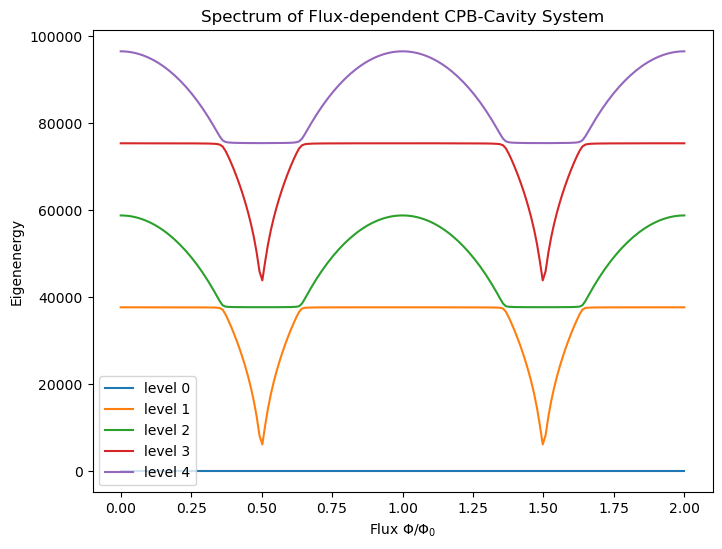

In [17]:
#varing flux value, explore the eigenvalues of total hamiltonian
#energy spectrum of flux-dependent CPB-cavity system
phi_value = np.linspace(0, 2, 200)
eigenvalues = []

for phi in phi_value:
    H_total = get_flux_hamiltonian(phi)
    eigs = H_total.eigenenergies()
    eigenvalues.append(eigs[:5])  #show lowest 5 levels

eigenvalues = np.array(eigenvalues)

plt.figure(figsize=(8,6))
for i in range(eigenvalues.shape[1]):
    plt.plot(phi_value, eigenvalues[:,i], label=f'level {i}')
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Eigenenergy")
plt.title("Spectrum of Flux-dependent CPB-Cavity System")
plt.legend()
plt.show()

Text(0, 0.5, 'occupation probabilities')

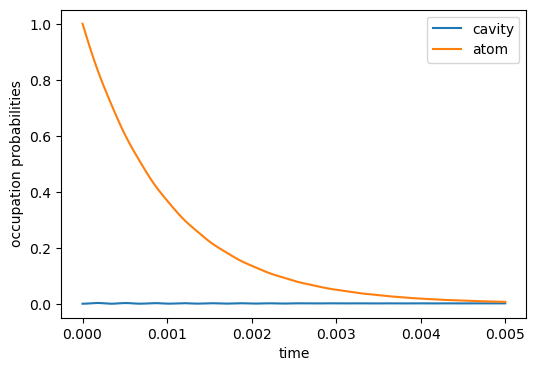

In [58]:
#time evolution
kappa = 1
gamma = 1e3
g = 80
n_th = 0.1

a_tensor = tensor(destroy(N_c), qeye(2))
sm_tensor = tensor(qeye(N_c), destroy(2))

#collapse operators
c_ops = []
c_ops.append(np.sqrt(kappa * (1 + n_th)) * a_tensor)  #cavity dissipation
c_ops.append(np.sqrt(kappa * n_th) * a_tensor.dag())  #cavity excitation
c_ops.append(np.sqrt(gamma) * sm_tensor)  #atom dissipation

#time evolution
psi0 = tensor(basis(N_c, 0), basis(2, 1))  #initial state
time = np.linspace(0, 5e-3, 1000)
H_total = get_flux_hamiltonian(1.0)
opts = Options(nsteps = 10000)
result = mesolve(H_total, psi0, time, c_ops, 
                 [a_tensor.dag() * a_tensor, sm_tensor.dag() * sm_tensor],
                options = opts)

#cavity and atom occupation number
n_c = result.expect[0]
n_a = result.expect[1]

fig, axe = plt.subplots(1,1, figsize = (6,4))
axe.plot(time, n_c, label = 'cavity')
axe.plot(time, n_a, label = 'atom')
axe.legend(loc = 0)
axe.set_xlabel('time')
axe.set_ylabel('occupation probabilities')

#overdamped, atom decaying rapidly
#qubit and cavity are not on resonance, no rabi oscillations observed

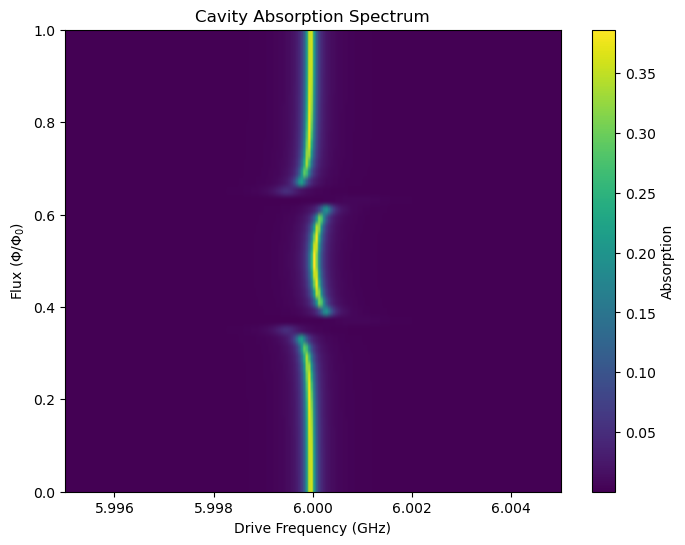

In [64]:
#sweeping the cavity frequency from 5.995GHz to 6.005GHz, while varying the applied flux
#parameters
Ej = 50e3
Ec = 230
ng = 0
g = 80
d = 0

f_c = 6e3
omega_c = 2 * np.pi * f_c

kappa = 1
gamma = 1e3
n_th = 0.1

N_q = 10  #qubit levels
N_c = 10  #cavity levels

a = tensor(destroy(N_c), qeye(2))
sm = tensor(qeye(N_c), destroy(2))

def get_E01(flux):
    #flux-dependent tunneling energy
    phi = 2*np.pi*flux
    cos_term = np.cos(phi/2)
    sin_term = np.sin(phi/2)
    Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

    #flux-dependent hamiltonian
    #CPB/ atom hamiltonian, in charge basis
    H_charging = np.diag(4*Ec*(np.arange(-N_q, N_q+1)-ng)**2)
    H_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N_q),1) + np.diag(np.ones(2*N_q), -1))
    H_phi = H_charging + H_tunneling 
    H_phi = Qobj(H_phi)

    #flux-dependent eigenenergies, eigenstates and first transition energy
    e_energy, e_state = H_phi.eigenstates()
    E01 = e_energy[1] - e_energy[0]
    return E01

#sweep parameters
flux_list = np.linspace(0, 1, 50)
freq_list = np.linspace(5.995e3, 6.005e3, 200)
omega_list = 2 * np.pi * freq_list
spectrum_list = []

for flux in flux_list:
    omega_q = 2 * np.pi * get_E01(flux)  #qubit frequency
    H = omega_c * a.dag() * a + omega_q * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())

    c_ops = []
    c_ops.append(np.sqrt(kappa * (1 + n_th)) * a)
    c_ops.append(np.sqrt(kappa * n_th) * a.dag())
    c_ops.append(np.sqrt(gamma) * sm)

    spec = spectrum(H, omega_list, c_ops, a.dag(), a)
    spectrum_list.append(spec)

spectrum_list = np.array(spectrum_list)

plt.figure(figsize=(8, 6))
plt.imshow(spectrum_list, aspect='auto', extent=[freq_list[0]/1e3, freq_list[-1]/1e3, flux_list[0], flux_list[-1]], origin='lower')
plt.colorbar(label='Absorption')
plt.xlabel('Drive Frequency (GHz)')
plt.ylabel('Flux ($\Phi/\Phi_0$)')
plt.title('Cavity Absorption Spectrum')
plt.show()